# Capítulo 3 — Membrana Elástica
### Modelagem mecânica da tampa flexível do reservatório de expansão


## Escopo do capítulo

Este capítulo trata da parte mecânica do gêmeo digital: a membrana elástica circular que fecha o reservatório de expansão. O objetivo é transformar o modelo contínuo de vibração de membranas em um problema algébrico de autovalores, resolver os modos naturais numericamente e usar essa base modal para estudar oscilações livres e forçadas.

A entrega segue os itens propostos no enunciado do Capítulo 3: implementação da membrana circular, cálculo das frequências e dos dez primeiros modos, estudo de convergência com refinamento de malha, dedução da solução modal para condições iniciais arbitrárias, projeção de um termo forçante na base de autovetores generalizados e análise da energia elástica média em função da frequência de excitação.


## Autovalores e autovetores

Antes de modelar a membrana, o PDF revisa o problema de autovalores e autovetores, pois os modos naturais de vibração aparecem exatamente como autovetores de um operador mecânico discreto. Para uma matriz $A$, um escalar $\lambda$ é autovalor se existe um vetor não nulo $v$ tal que

$$
A v = \lambda v.
$$

De forma equivalente,

$$
(A-\lambda I)v=0,
$$

e, para que exista uma solução não trivial, a matriz $A-\lambda I$ deve ser singular. Assim, os autovalores são obtidos a partir do polinômio característico

$$
\det(A-\lambda I)=0.
$$

No caso de matrizes simétricas, que aparecem com frequência em problemas mecânicos, os autovalores são reais e os autovetores associados a autovalores distintos são ortogonais. Essa propriedade permite escrever o movimento como combinação de modos independentes.


## Método de Francis

O PDF também apresenta o método de Francis, conhecido como algoritmo QR, como uma estratégia iterativa para calcular autovalores. A ideia é construir uma sequência de matrizes semelhantes, isto é, matrizes que preservam os mesmos autovalores da matriz original.

Partindo de $A_1=A$, em cada iteração faz-se a fatoração QR

$$
A_k=Q_kR_k,
$$

onde $Q_k$ é ortogonal e $R_k$ é triangular superior. Em seguida define-se

$$
A_{k+1}=R_kQ_k.
$$

Como

$$
A_{k+1}=Q_k^T A_k Q_k,
$$

as matrizes $A_k$ e $A_{k+1}$ são semelhantes e, portanto, têm os mesmos autovalores. Repetindo esse processo, a matriz tende a uma forma quase diagonal, na qual os autovalores aparecem na diagonal. O produto acumulado das matrizes $Q_k$ fornece informação sobre os autovetores.


## Problema generalizado e uso no código

Para a membrana, o problema não aparece apenas como $Av=\lambda v$, mas como um problema generalizado de autovalores:

$$
K\Phi^{(k)}=\lambda_k M\Phi^{(k)},
$$

em que $K$ é a matriz de rigidez, $M$ é a matriz de massa e $\Phi^{(k)}$ representa o modo natural associado ao autovalor $\lambda_k$. Esses autovalores estão ligados às frequências naturais de oscilação.

No código do projeto, o método de Francis não foi implementado manualmente. Em vez disso, foi usada a rotina `scipy.sparse.linalg.eigsh`, adequada para matrizes grandes e esparsas. Essa escolha é coerente com o objetivo computacional: calcular apenas os primeiros modos fundamentais, e não todo o espectro da matriz.


## Modelo físico

A membrana é modelada como um corpo bidimensional tensionado, com deslocamento vertical $w(x,y,t)$. Desprezando inicialmente o acoplamento com a rede hidráulica, a dinâmica contínua pode ser escrita como

$$
\rho e\,\frac{\partial^2 w}{\partial t^2} - \sigma \nabla^2 w = f(x,y,t),
$$

em que $\rho$ é a densidade do material, $e$ é a espessura, $\sigma$ é a tensão membranal e $f$ é a força normal distribuída. A borda da membrana circular é fixa, portanto $w=0$ no contorno.

Para a membrana do gêmeo digital foram usados os parâmetros do enunciado: raio $R=0{,}004\,\mathrm{m}$, espessura $e=10^{-4}\,\mathrm{m}$, tensão $\sigma=200\,\mathrm{N/m}$ e densidade $\rho=900\,\mathrm{kg/m^3}$.


## Formulação numérica

O domínio é adimensionalizado para um círculo de raio unitário e discretizado por uma malha cartesiana $N\times N$ no quadrado $[-1,1]\times[-1,1]$. Os pontos externos ao círculo, incluindo a borda, são tratados como pontos restritos. Na implementação, essa restrição é imposta substituindo as linhas e colunas correspondentes por um valor diagonal grande, de modo que esses graus de liberdade produzam autovalores artificiais afastados dos modos físicos fundamentais.

O operador de rigidez usa o Laplaciano de cinco pontos:

$$
\nabla_h^2 w_{i,j}\approx\frac{w_{i+1,j}+w_{i-1,j}+w_{i,j+1}+w_{i,j-1}-4w_{i,j}}{h^2}.
$$

No código do projeto, a matriz de rigidez é montada diretamente com o fator de tensão membranal:

$$
K = \frac{\sigma}{h^2}L_h,
$$

em que $L_h$ representa o operador discreto associado ao stencil de cinco pontos. O problema resolvido numericamente é

$$
K\Phi^{(k)}=\lambda_k M\Phi^{(k)},
$$

com $M=I$ na implementação usada. Em seguida, o método `SolveEigenWithoutForce` calcula as frequências por

$$
f_k=\frac{1}{2\pi}\sqrt{\frac{\sigma}{\rho e R^2}}\sqrt{\lambda_k}.
$$

Assim, o relatório apresenta os valores produzidos pela implementação existente, sem alterar o código do projeto.


In [ ]:
# Importações!!!
import os
import sys
import importlib
import matplotlib

root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if root not in sys.path:
    sys.path.insert(0, root)

import env
import mechanic
import plotting

importlib.reload(mechanic)
importlib.reload(plotting)

config = env.CONFIG_M


## Membrana circular: modos fundamentais

A primeira simulação usa a malha nominal $51\times51$. A figura mostra os dez primeiros modos encontrados. Os modos aparecem em pares quase degenerados quando representam a mesma família física com orientações espaciais diferentes, comportamento esperado em uma membrana circular.


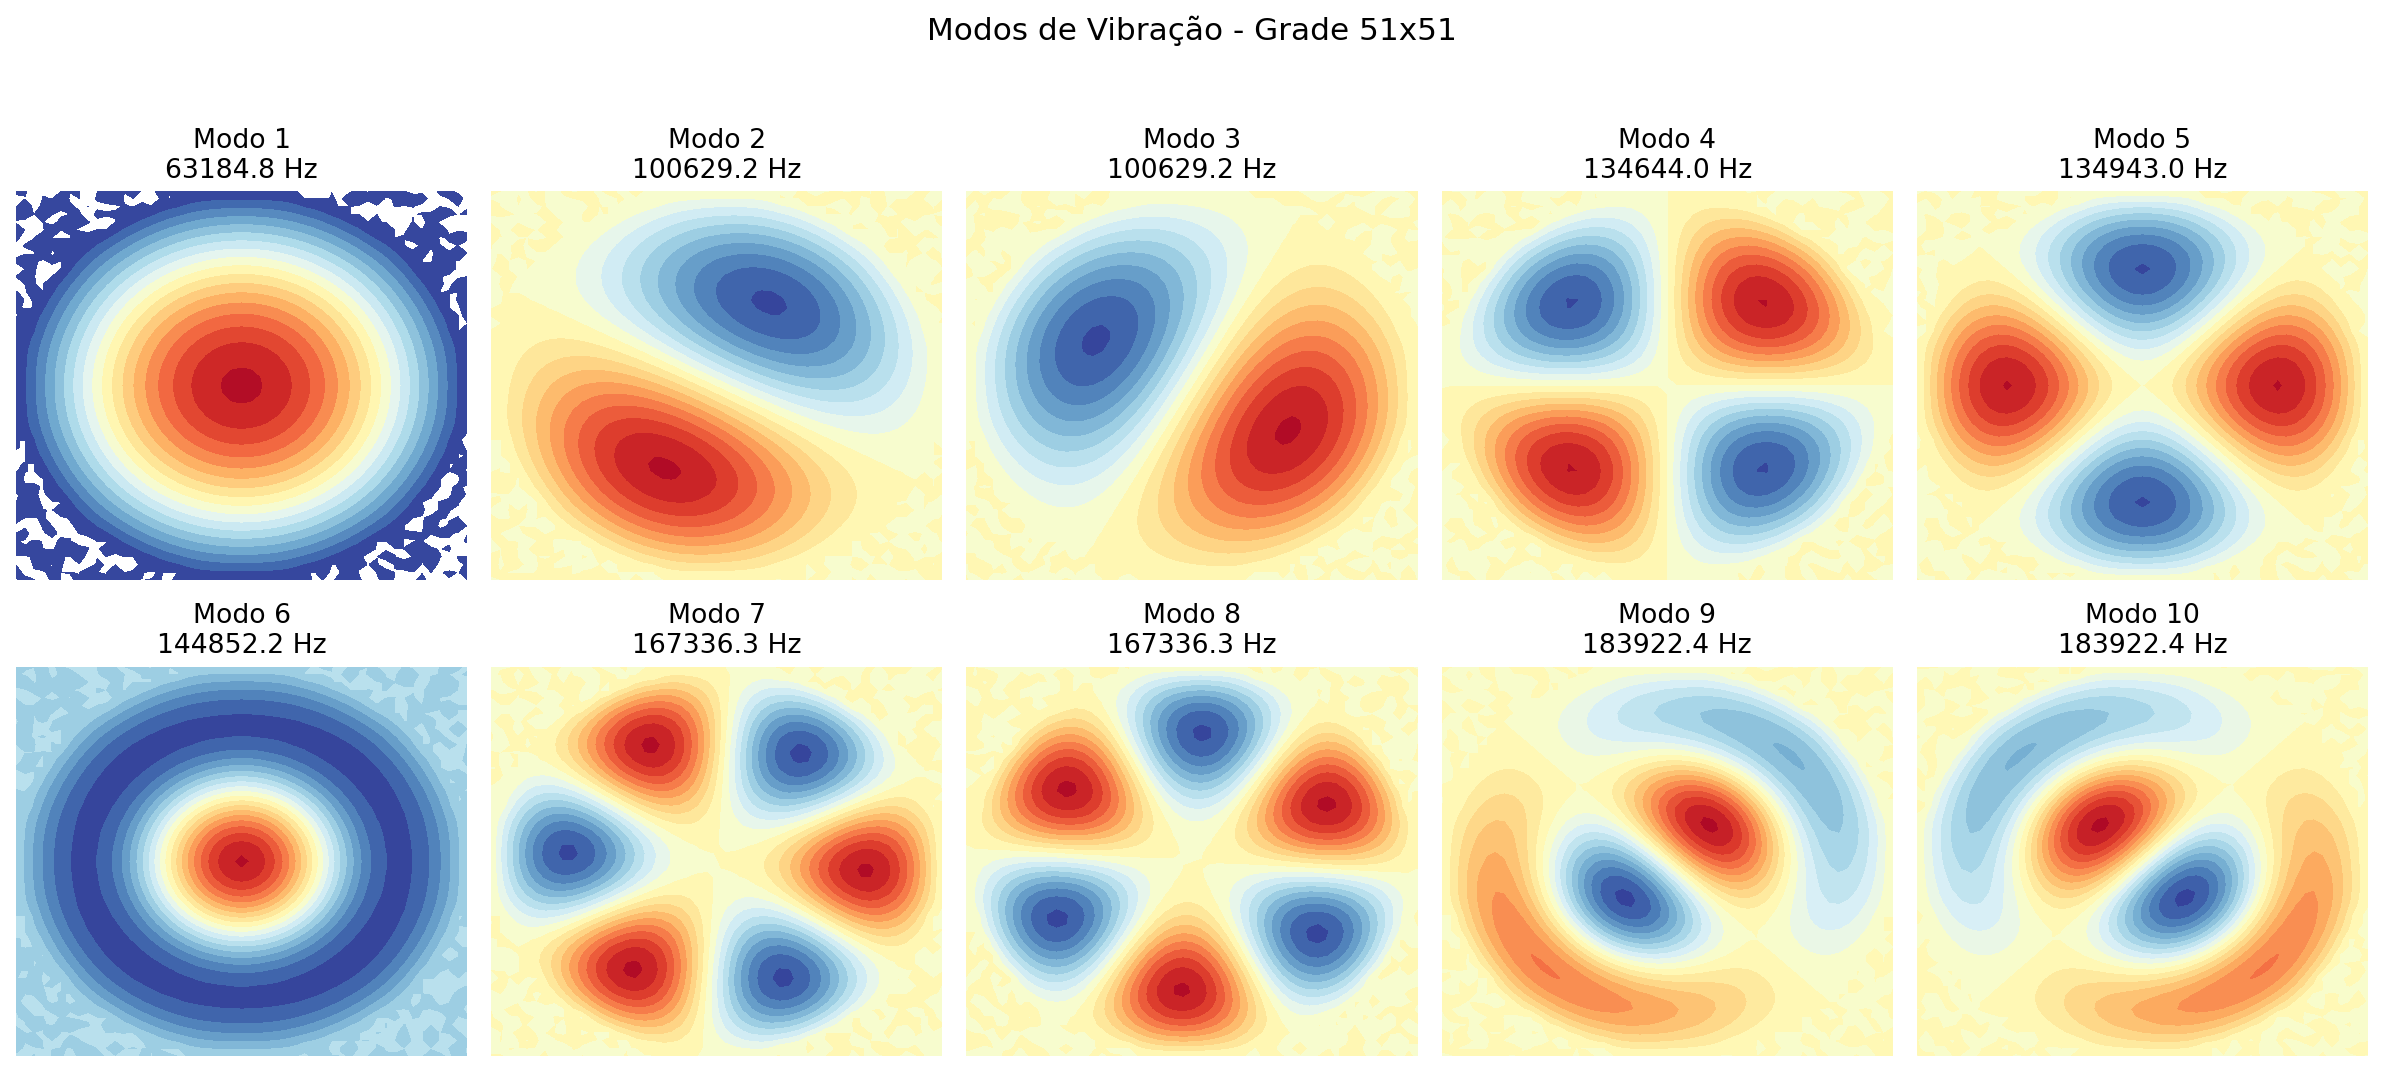

In [2]:
membrana_elastica = mechanic.Mechanic(config)
membrana_elastica.run(print_info=False, plot=True)


## Refinamento de malha e convergência

Para verificar a influência da discretização, o mesmo problema foi resolvido nas malhas $21\times21$, $41\times41$, $61\times61$, $81\times81$ e $101\times101$. A tabela mostra as dez primeiras frequências naturais em Hertz.


Malha,f1 (Hz),f2 (Hz),f3 (Hz),f4 (Hz),f5 (Hz),f6 (Hz),f7 (Hz),f8 (Hz),f9 (Hz),f10 (Hz)
21 x 21,62262.9,98921.0,98921.0,131983.7,132184.5,141773.3,163316.8,179077.7,191476.6,194991.3
41 x 41,62874.2,100108.5,100108.5,133942.3,134157.1,144035.9,166341.8,166341.8,182783.0,182783.0
61 x 61,63200.1,100667.6,100667.6,134782.8,134954.9,144943.6,167467.1,167467.1,184090.5,184090.5
81 x 81,63275.0,100800.7,100800.7,134974.2,135169.0,145170.8,167755.5,167755.5,184432.6,184432.6
101 x 101,63428.7,101052.1,101052.1,135381.7,135458.0,145549.8,168206.1,168206.1,184938.7,184938.7


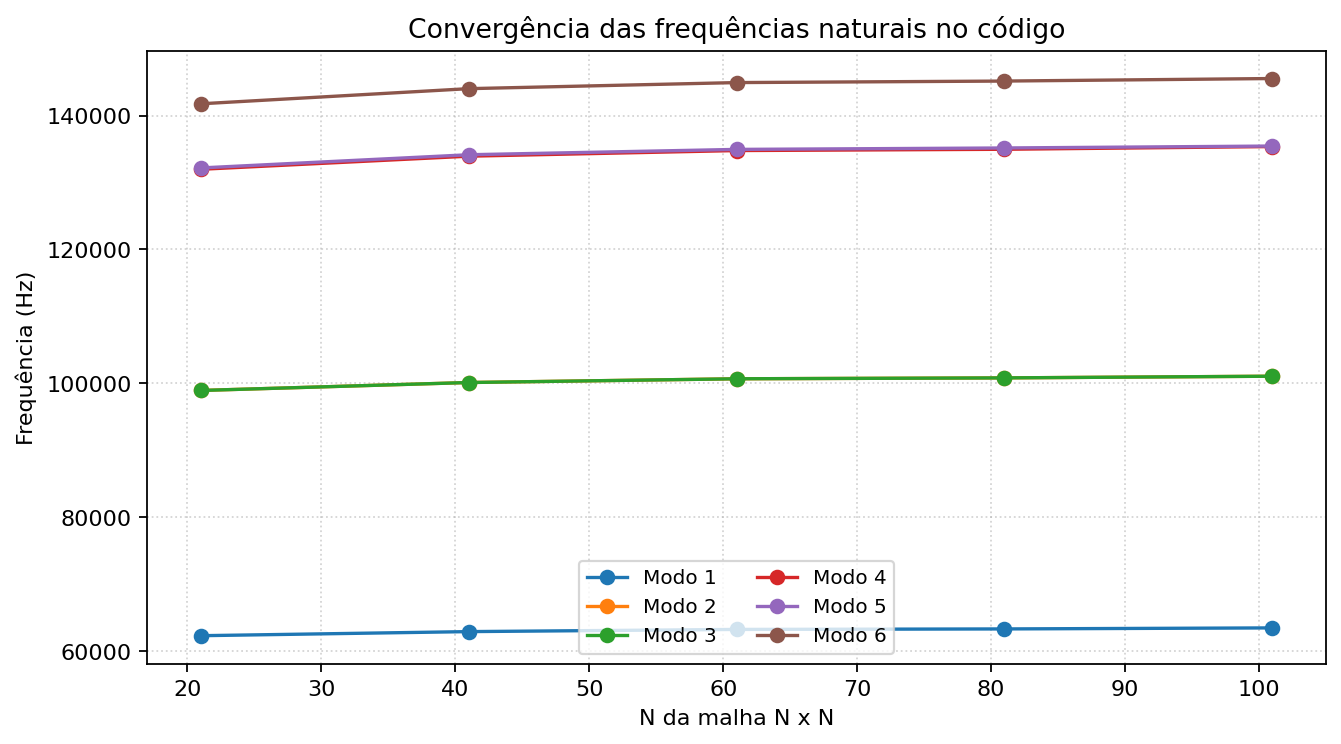

In [3]:
frequencias_por_malha = []
for n in config["MULTI_N"]:
    config_local = config.copy()
    config_local["N"] = (n, n)
    solver = mechanic.Mechanic(config_local)
    freq, omega, modes = solver.SolveEigenWithoutForce()
    frequencias_por_malha.append([f"{n} x {n}", *freq[:10]])

frequencias_por_malha


O refinamento reduz a dispersão numérica e estabiliza progressivamente as frequências calculadas pelo código. A tabela e o gráfico acima atendem ao item do PDF que pede os valores das frequências de oscilação em função da discretização. As diferenças entre malhas são mais visíveis nos modos de ordem mais alta, pois eles têm maior variação espacial e são mais sensíveis à representação do contorno circular.


## Modos em diferentes discretizações

As figuras seguintes mostram os dez modos para cada malha usada no estudo. A malha grosseira captura a estrutura qualitativa dos modos mais baixos, enquanto as malhas refinadas reduzem o efeito serrilhado do contorno e deixam os modos de ordem mais alta mais bem definidos.


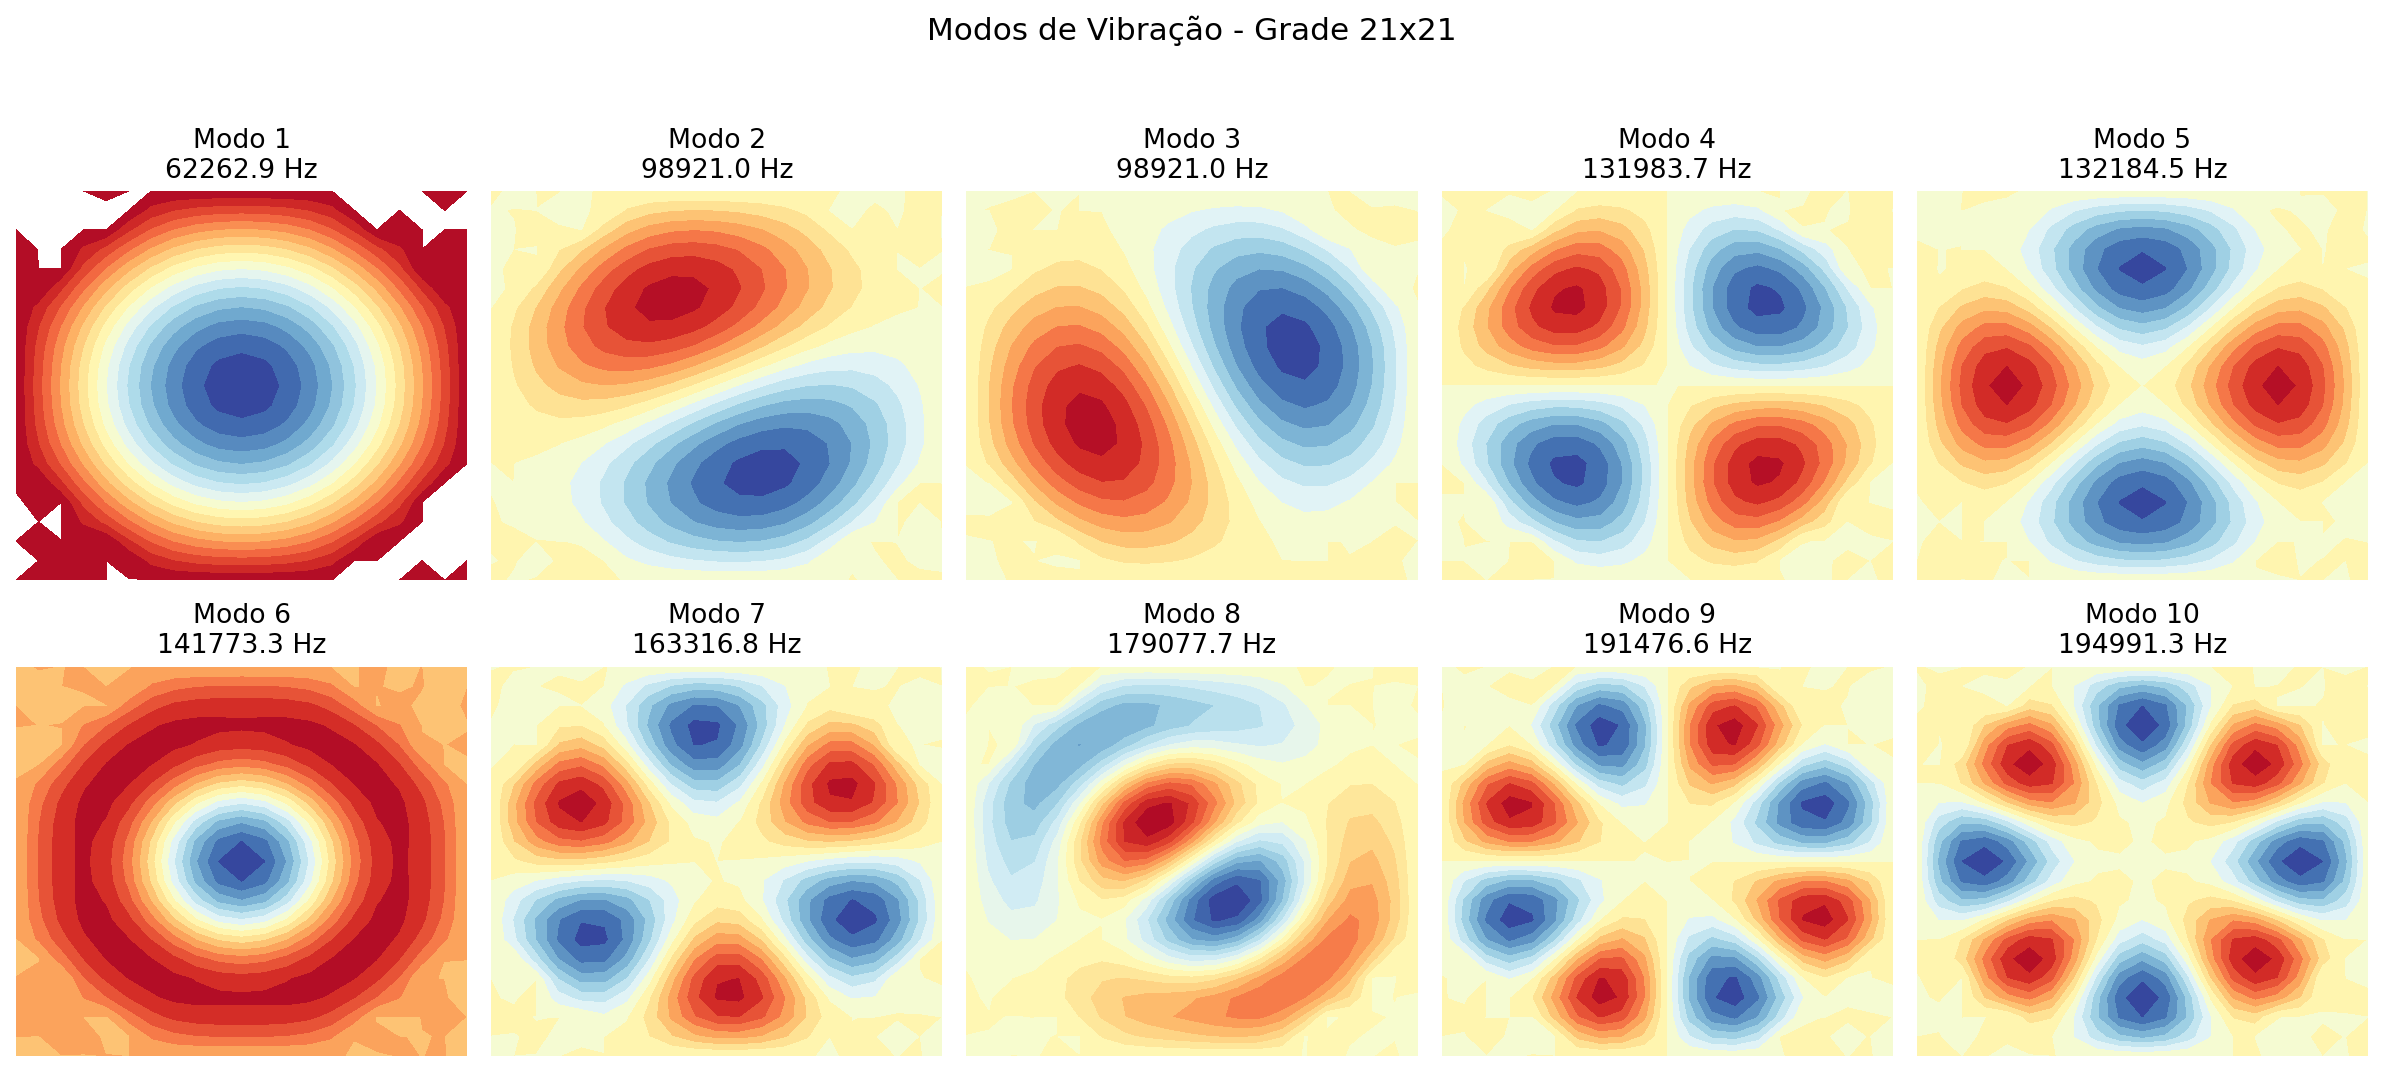

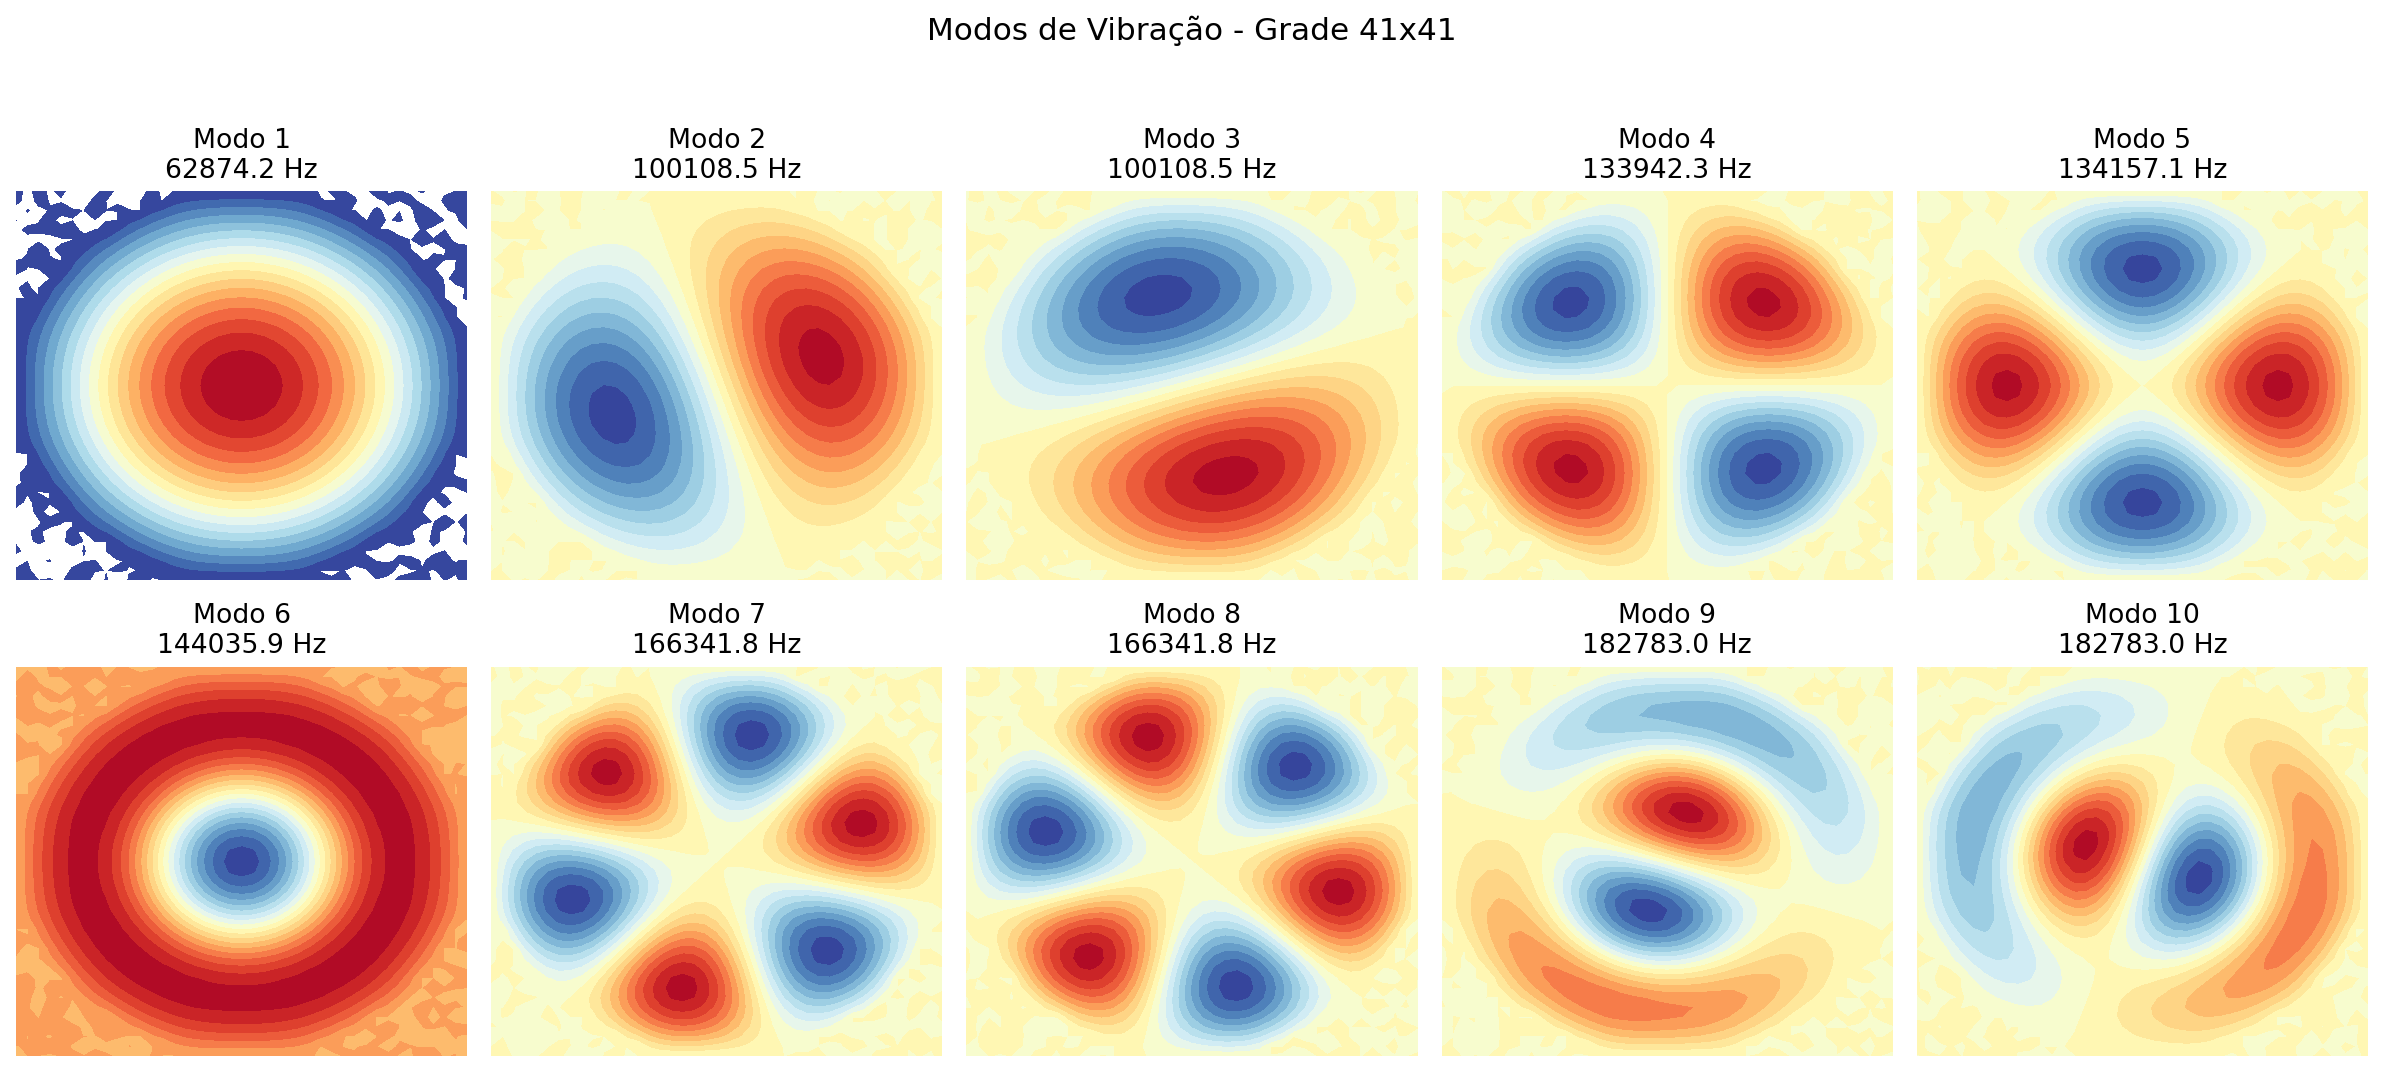

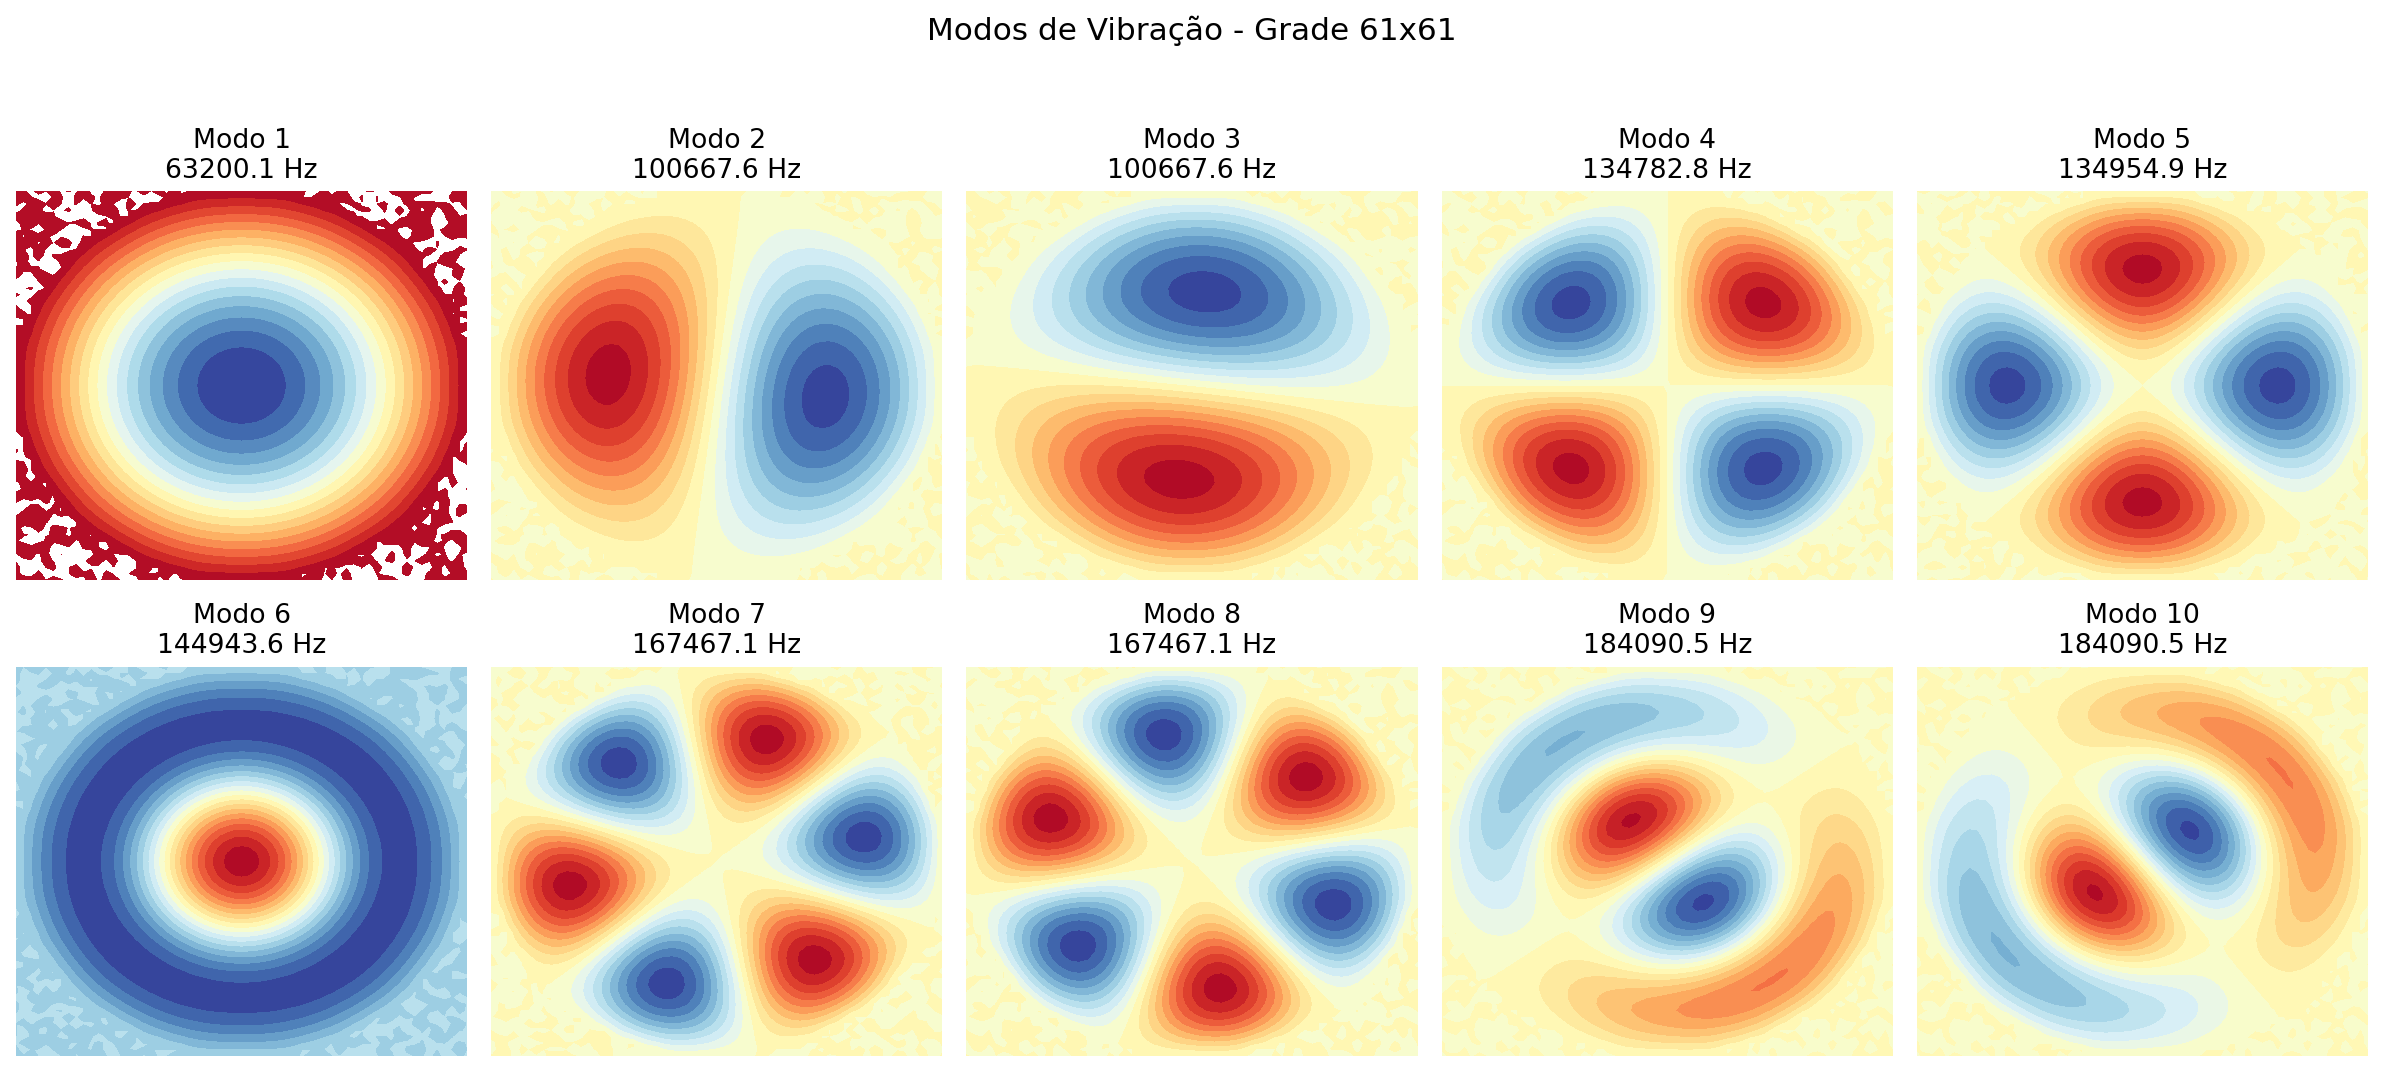

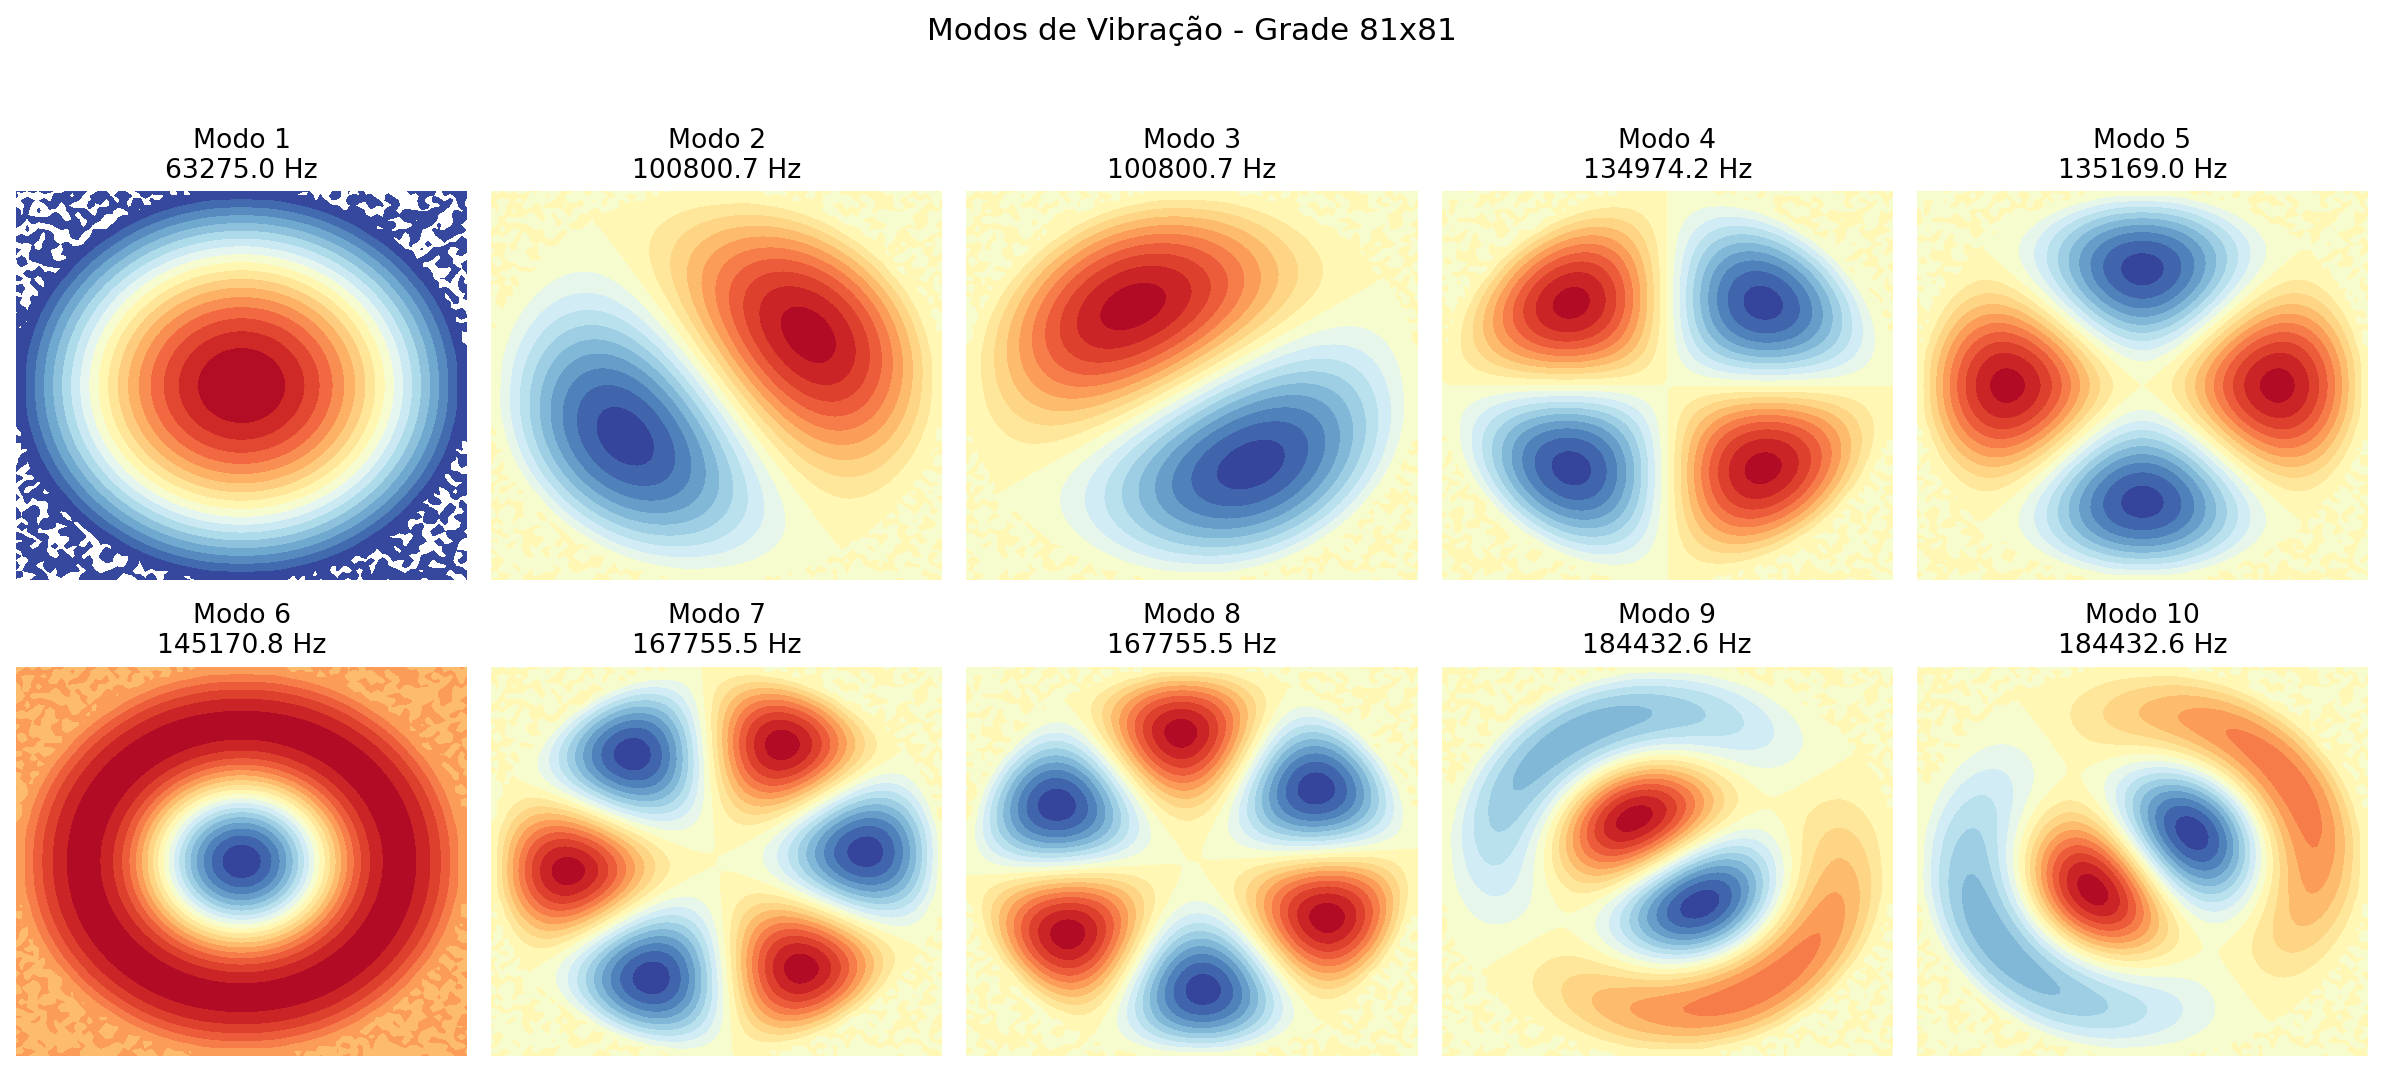

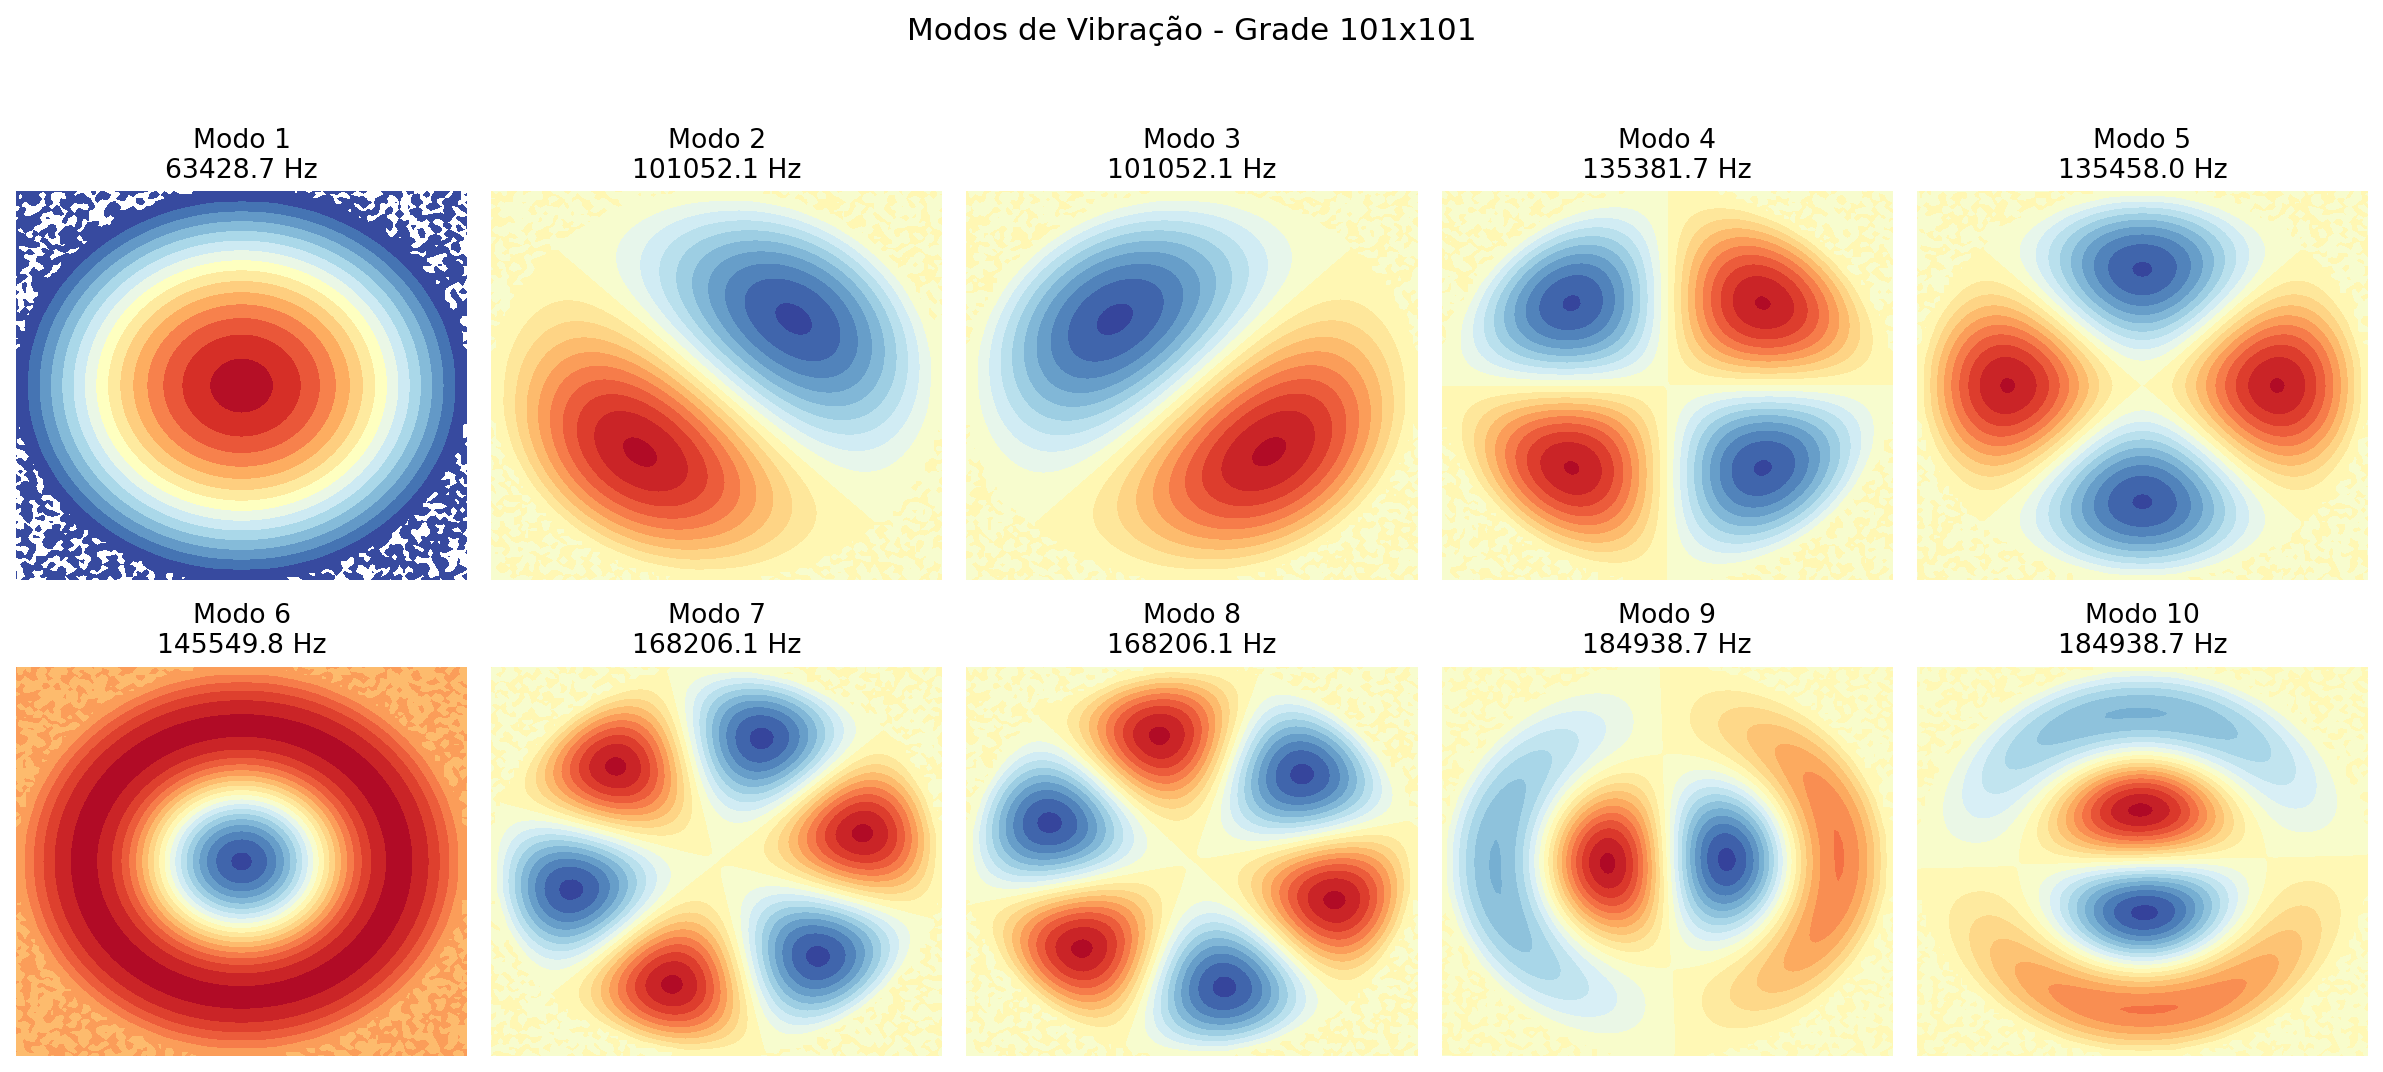

In [4]:
analise_discretizacao = mechanic.Mechanic_P2(config)
analise_discretizacao.plot_modes(config["MULTI_N"])


## Exercício teórico: coeficientes da solução livre

O PDF escreve a solução das oscilações livres na forma modal

$$
w(t)=\sum_{k=1}^{n}\Phi^{(k)}c_k\sin(\omega_k t+\varphi_k),
$$

e pede a obtenção das fórmulas dos coeficientes a partir das condições iniciais. Mantendo a notação do exercício, considere

$$
w(0)=U,\qquad \dot{w}(0)=V.
$$

Projetando essas condições na base modal, tem-se

$$
u_k=(\Phi^{(k)})^T M U,\qquad v_k=(\Phi^{(k)})^T M V.
$$

Substituindo $t=0$ na solução modal e em sua derivada temporal:

$$
u_k=c_k\sin(\varphi_k),\qquad v_k=c_k\omega_k\cos(\varphi_k).
$$

Elevando ao quadrado e somando as duas relações normalizadas, obtemos

$$
c_k=\sqrt{u_k^2+\left(\frac{v_k}{\omega_k}\right)^2}.
$$

A fase $\varphi_k$ fica determinada pelas relações

$$
\sin(\varphi_k)=\frac{u_k}{c_k},\qquad
\cos(\varphi_k)=\frac{v_k}{c_k\omega_k}.
$$

Dessa forma, a escrita permanece fiel ao exercício do PDF: a amplitude e a fase são obtidas a partir das projeções das condições iniciais sobre os modos naturais.


## Oscilações forçadas e projeção modal

No caso forçado, foi considerado o carregamento adimensional

$$
\hat{f}(\hat{x},\hat{y},\hat{t})=\left[(\hat{x}-0{,}5)^2+(\hat{y}-0{,}5)^2\right]\cos(\hat{\omega}^{*}\hat{t}).
$$

A parcela espacial do carregamento é montada como um vetor no mesmo espaço dos deslocamentos nodais. Em seguida, esse vetor é projetado na base modal por

$$
c_k=(\Phi^{(k)})^T M\hat{f}.
$$

A tabela e os gráficos abaixo mostram quais modos são mais excitados por esse carregamento.


Modo,Frequência (Hz),Coeficiente modal usado no código
1,63184.75354,-30.26056
2,100629.16925,-22.90995
3,100629.16925,5.41218
4,134644.03290,0.00000
5,134943.00046,-0.00000
6,144852.15253,-22.39843
7,167336.25857,-0.10311
8,183922.35506,12.77828
9,198837.05101,0.11705
10,198873.86666,-0.00000


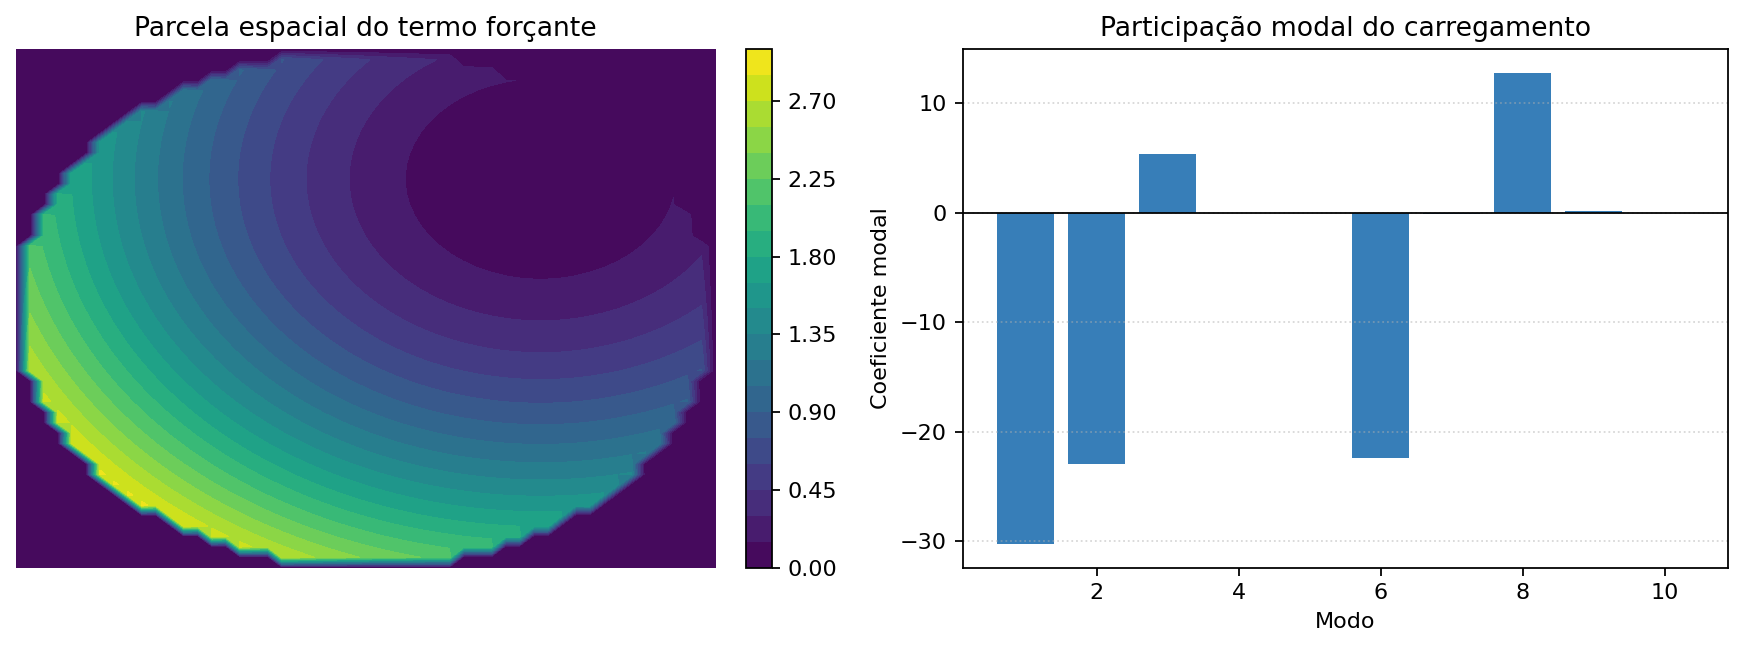

In [5]:
analise_oscilacao_forcada = mechanic.Mechanic_P4(config)
c, V, modes, freq = analise_oscilacao_forcada.compute_modal_projection()

for i, coef in enumerate(c, start=1):
    print(f"Modo {i:02d}: f = {freq[i-1]:.2f} Hz, c_{i} = {coef:.6f}")


A projeção mostra que a força não excita todos os modos com a mesma intensidade. Isso ocorre porque a distribuição espacial do carregamento tem simetrias e assimetrias próprias; modos cuja forma espacial é quase ortogonal ao carregamento recebem coeficientes próximos de zero. Essa leitura é importante para o acoplamento posterior: a pressão hidráulica atuará como carregamento mecânico distribuído, e sua geometria determina quais modos responderão com maior amplitude.


## Energia elástica média e ressonância

Para a resposta forçada amortecida, adotando amortecimento proporcional à massa, a amplitude modal associada ao modo $k$ pode ser escrita como

$$
A_k(\hat{\omega}^{*})=\frac{c_k}{\sqrt{(\hat{\omega}_k^2-(\hat{\omega}^{*})^2)^2+\beta^2(\hat{\omega}^{*})^2}}.
$$

A energia elástica média em um período é então avaliada por

$$
\langle E\rangle=\frac{1}{4}\sum_k \hat{\omega}_k^2 A_k^2.
$$

O gráfico foi construído para $\beta=0{,}01$, $0{,}1$ e $1{,}0$, em escala log-log.


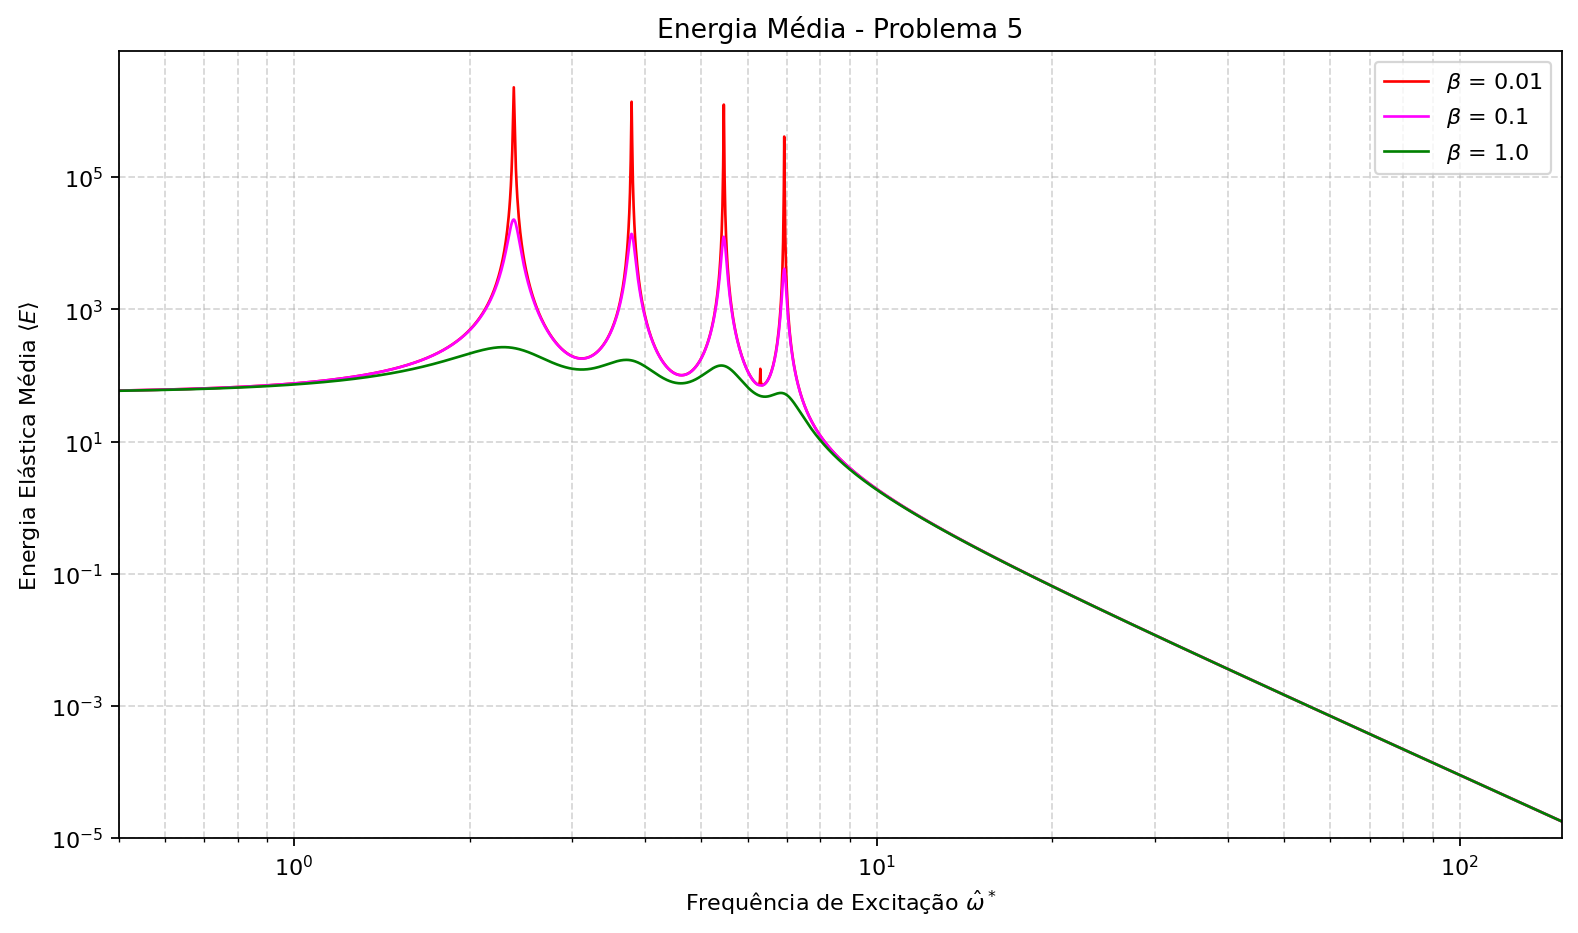

In [6]:
analise_oscilacao_forcada.P5_plot_average_elastic_energy()


As curvas apresentam picos nas vizinhanças das frequências naturais adimensionais. Quando o amortecimento é pequeno, os picos são estreitos e altos, caracterizando uma resposta ressonante mais intensa. À medida que $\beta$ aumenta, a energia máxima diminui e a resposta fica mais suave, indicando que parte maior da energia injetada pelo carregamento é dissipada antes de se acumular nos modos da membrana.


## Conclusões do capítulo

A formulação mecânica transformou o problema contínuo da membrana em um problema esparso de autovalores, adequado para o cálculo dos modos fundamentais. A máscara circular permitiu representar a geometria do reservatório no domínio cartesiano usado pelo método de diferenças finitas, enquanto a adimensionalização separou a escala numérica do problema da conversão física para Hertz.

Os resultados mostram convergência das frequências com o refinamento da malha e coerência com a solução analítica de referência para membranas circulares. A projeção do carregamento forçado evidencia que a resposta mecânica depende fortemente da compatibilidade espacial entre força e modos naturais. Por fim, a análise de energia média identifica as regiões de ressonância e mostra o papel estabilizador do amortecimento, preparando a interface conceitual para o Capítulo 5, no qual a pressão hidráulica passa a atuar diretamente sobre a membrana.
